# Baseline Modeling

TF-IDF + K-Means + Hierarchical Ward baselines on chunk-level data. Baseline `k` matches the HDBSCAN non-noise cluster count from `chunk_cluster_labels`.

In [2]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, warnings, seaborn as sns
from pathlib import Path
from google.cloud import bigquery
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize
import shutil, sys
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='tab10')

_nb = globals().get('__vsc_ipynb_file__', None)
if _nb:
    REPO_ROOT = Path(_nb).parent.parent
else:
    _cwd = Path.cwd()
    REPO_ROOT = _cwd if (_cwd / 'gcp_config.py').exists() else _cwd.parent

OUT_DIR = REPO_ROOT / 'data'
OUT_DIR.mkdir(exist_ok=True)
FIGURES_DIR = OUT_DIR / 'figures'
FIGURES_DIR.mkdir(exist_ok=True)
RESULTS_DIR = OUT_DIR / 'results'
RESULTS_DIR.mkdir(exist_ok=True)

sys.path.insert(0, str(REPO_ROOT))
from gcp_config import PROJECT_ID, bq_table
client = bigquery.Client(project=PROJECT_ID)

df = client.query(f"""
    SELECT
        chunk_uid,
        conversation_id,
        cluster_id,
        original_chunk_text AS text
    FROM `{bq_table('chunk_cluster_labels')}`
    ORDER BY chunk_uid
""").to_dataframe()

N = int(client.query(f"""
    SELECT COUNT(DISTINCT cluster_id) AS k
    FROM `{bq_table('chunk_cluster_labels')}`
    WHERE NOT is_noise
""").to_dataframe()['k'][0])
if N < 1:
    N = 24  # fallback if labels missing

n_noise = int((df['cluster_id'] == -1).sum())
print(f"Chunks: {len(df):,} (HDBSCAN noise rows: {n_noise:,}) | k (non-noise cluster count)={N}")

texts = [t if str(t).strip() else ' ' for t in df['text'].fillna('').astype(str).tolist()]
lbl   = 'TF-IDF + LSA on chunk text (k = HDBSCAN non-noise cluster count)'


Chunks: 169,709 (HDBSCAN noise rows: 20,346) | k (non-noise cluster count)=24


## TF-IDF baselines: K-Means, Hierarchical Ward, silhouette sweep

TF-IDF (169709, 15000) → LSA (169709, 150)  variance=31.5%
K-Means      k=24  sil=0.1383  DB=2.5349  CH=3691.8
Hierarchical fit on 10,000-chunk subsample → labels extended via nearest centroid
Hierarchical k=24  sil=0.1420  DB=2.5718  CH=3744.5


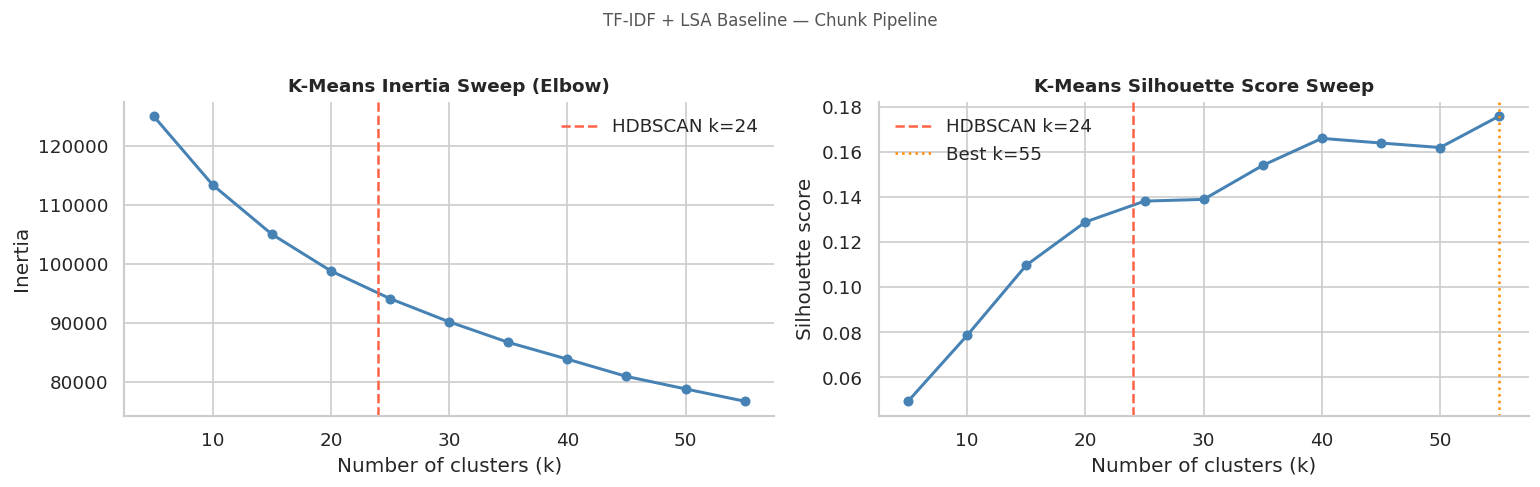

Best k by silhouette: 55  score=0.1759

Top 8 TF-IDF terms per K-Means cluster — TF-IDF + LSA on chunk text (k = HDBSCAN non-noise cluster count):
  C  0 (n=5064): ai, 10web, person, user, assist, website, hi, ai hi
  C  1 (n=8678): ai, plan, free, website, 10web, trial, websites, like
  C  2 (n=8786): ai, user, support, chat, url, person, received, thank
  C  3 (n=5884): ai, chat, ll, support, haven, user, heard, haven heard
  C  4 (n=2330): ai, para, site, você, que, um, se, 10web
  C  5 (n=13822): ai, user, agent, person, live, url, connect, let
  C  6 (n=11475): ai, subscription, website, account, password, cancel, email, click
  C  7 (n=5235): ai, browser, cache, 10web, website, data, dashboard, clear
  C  8 (n=3605): vous, ai, le, votre, pour, les, site, je
  C  9 (n=1761): ai, il, di, sito, se, la, tuo, user
  C 10 (n=11446): domain, ai, dns, 10web, record, records, add, ssl
  C 11 (n=10887): ai, user, person, url, 10web, 翻译的, location, کنید
  C 12 (n=3121): ai, user, rate, supp

In [4]:
all_results = []
tfidf = TfidfVectorizer(max_features=15000, stop_words=None, ngram_range=(1, 2),
                        min_df=3, sublinear_tf=True)
X = tfidf.fit_transform(texts)
svd = TruncatedSVD(n_components=150, random_state=42)
X_lsa = normalize(svd.fit_transform(X))
print(f'TF-IDF {X.shape} → LSA {X_lsa.shape}  variance={svd.explained_variance_ratio_.sum():.1%}')

km = KMeans(n_clusters=N, random_state=42, n_init=10)
km_labels = km.fit_predict(X_lsa)
df['baseline_kmeans'] = km_labels
sil_km = silhouette_score(X_lsa, km_labels, sample_size=min(500, len(df)), random_state=42)
db_km  = davies_bouldin_score(X_lsa, km_labels)
ch_km  = calinski_harabasz_score(X_lsa, km_labels)
print(f'K-Means      k={N}  sil={sil_km:.4f}  DB={db_km:.4f}  CH={ch_km:.1f}')

MAX_AGG = 10_000
rng = np.random.default_rng(42)
if len(X_lsa) > MAX_AGG:
    idx_sub = rng.choice(len(X_lsa), MAX_AGG, replace=False)
    X_agg = X_lsa[idx_sub]
else:
    idx_sub = np.arange(len(X_lsa))
    X_agg = X_lsa

agg = AgglomerativeClustering(n_clusters=N, linkage='ward')
agg_sub_labels = agg.fit_predict(X_agg)

if len(X_lsa) > MAX_AGG:
    from sklearn.neighbors import NearestCentroid
    nc = NearestCentroid()
    nc.fit(X_agg, agg_sub_labels)
    agg_labels = nc.predict(X_lsa)
    print(f'Hierarchical fit on {MAX_AGG:,}-chunk subsample → labels extended via nearest centroid')
else:
    agg_labels = agg_sub_labels

df['baseline_hierarchical'] = agg_labels
sil_agg = silhouette_score(X_lsa, agg_labels, sample_size=min(500, len(df)), random_state=42)
db_agg  = davies_bouldin_score(X_lsa, agg_labels)
ch_agg  = calinski_harabasz_score(X_lsa, agg_labels)
print(f'Hierarchical k={N}  sil={sil_agg:.4f}  DB={db_agg:.4f}  CH={ch_agg:.1f}')

_k_hi = max(55, int(np.ceil(N / 5) * 5))
k_range, sils, inerts = list(range(5, _k_hi + 1, 5)), [], []
for k in k_range:
    m = KMeans(n_clusters=k, random_state=42, n_init=5).fit(X_lsa)
    sils.append(silhouette_score(X_lsa, m.labels_, sample_size=min(300, len(df)), random_state=42))
    inerts.append(m.inertia_)
best_k = k_range[np.argmax(sils)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(k_range, inerts, 'o-', color='steelblue', linewidth=1.8, ms=5)
axes[0].axvline(N, color='tomato', ls='--', lw=1.5, label=f'HDBSCAN k={N}')
axes[0].set_title('K-Means Inertia Sweep (Elbow)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].legend(frameon=False)
sns.despine(ax=axes[0])

axes[1].plot(k_range, sils, 'o-', color='steelblue', linewidth=1.8, ms=5)
axes[1].axvline(N, color='tomato', ls='--', lw=1.5, label=f'HDBSCAN k={N}')
axes[1].axvline(best_k, color='darkorange', ls=':', lw=1.5, label=f'Best k={best_k}')
axes[1].set_title('K-Means Silhouette Score Sweep', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette score')
axes[1].legend(frameon=False)
sns.despine(ax=axes[1])

fig.suptitle('TF-IDF + LSA Baseline — Chunk Pipeline', fontsize=10, color='#555555', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'kmeans_sweep.png', bbox_inches='tight')
plt.show()
print(f'Best k by silhouette: {best_k}  score={max(sils):.4f}')

noise_pct = round(100 * (df.cluster_id == -1).mean(), 1)

print(f'\nTop 8 TF-IDF terms per K-Means cluster — {lbl}:')
for i in range(N):
    ct = [t for t, l in zip(texts, km_labels) if l == i]
    if len(ct) < 2: continue
    v = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 2), min_df=2)
    mat = v.fit_transform(ct)
    top = mat.mean(axis=0).A1.argsort()[::-1][:8]
    print(f'  C{i:3d} (n={len(ct):4d}): {", ".join(v.get_feature_names_out()[top])}')

df[['chunk_uid', 'conversation_id', 'cluster_id', 'baseline_kmeans', 'baseline_hierarchical']].to_csv(
    RESULTS_DIR / 'baseline_labels.csv', index=False)

for method, sil, db, ch in [('TF-IDF + K-Means', sil_km, db_km, ch_km),
                              ('TF-IDF + Hierarchical Ward', sil_agg, db_agg, ch_agg)]:
    all_results.append({'label': lbl, 'method': method,
                         'n_clusters': N, 'noise_pct': 0.0,
                         'silhouette': round(sil, 4), 'davies_bouldin': round(db, 4),
                         'calinski_harabasz': round(ch, 1)})
all_results.append({'label': lbl,
                    'method': 'Vertex AI Embeddings + HDBSCAN',
                    'n_clusters': N, 'noise_pct': noise_pct,
                    'silhouette': '→ NB06', 'davies_bouldin': '→ NB06', 'calinski_harabasz': '→ NB06'})


summary_df = pd.DataFrame(all_results)
summary_df.to_csv(RESULTS_DIR / 'baseline_summary.csv', index=False)
print('COMPARISON SUMMARY')
print(summary_df.to_string(index=False))